# VocalCoach — Inference Demo

Runs full offline coaching analysis against the VocalCoach API server.  
**Prerequisite:** API server must be running:
```bash
PYTHONPATH=. VOCALCOACH_CHECKPOINT=vocalcoach/runs/default/checkpoints/best_loss.pth \
  uvicorn vocalcoach.api:app --host 0.0.0.0 --port 8000
```

In [58]:
import requests, json, pathlib, IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

API_BASE = "http://localhost:8000"

# Check server is up
r = requests.get(f"{API_BASE}/health")
print(json.dumps(r.json(), indent=2))

{
  "status": "ok",
  "model_loaded": true,
  "device": "cuda",
  "cuda_available": true
}


## 1. Upload audio and run analysis

In [59]:
import os, pathlib

# Resolve repo root so relative paths work regardless of Jupyter launch dir
_HERE = pathlib.Path(os.getcwd())
_REPO = _HERE
for _candidate in [_HERE] + list(_HERE.parents):
    if (_candidate / "vocalcoach").is_dir():
        _REPO = _candidate
        break

AUDIO_FILE     = str(_REPO / "evalrecordings" / "house.wav")   # ← change to your file
REFERENCE_FILE = None   # e.g. str(_REPO / "evalrecordings" / "reference.wav")

print(f"Repo root   : {_REPO}")
print(f"Audio file  : {AUDIO_FILE}  (exists={pathlib.Path(AUDIO_FILE).exists()})")

files = {"audio": open(AUDIO_FILE, "rb")}
if REFERENCE_FILE:
    files["reference"] = open(REFERENCE_FILE, "rb")

r = requests.post(f"{API_BASE}/analyse", files=files)
report = r.json()

if r.status_code != 200:
    print(f"ERROR {r.status_code}:", report.get("detail", report))
else:
    print(f"\nStatus: {r.status_code}")
    print(f"Clip duration: {report.get('clip_duration_s')}s")
    print(f"Phrases detected: {report.get('n_phrases')}")

Repo root   : /home/sraja/NanoPitch-MusicalAI
Audio file  : /home/sraja/NanoPitch-MusicalAI/evalrecordings/house.wav  (exists=True)

Status: 200
Clip duration: 16.0s
Phrases detected: 1


## 2. Coaching score & observations

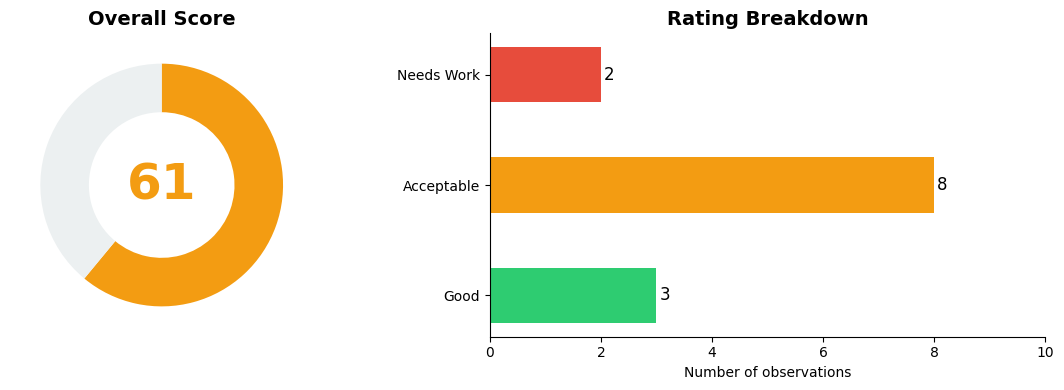


📋 Summary
────────────────────────────────────────────────────────────
Mean singing pitch is 254.1 Hz (B3) — cleanly detected across voiced phrases. Priority focus: Pitch instability detected (±142.7 cents std) — significant wavering or drift.


In [60]:
coaching = report["coaching"]

# ── Overall score gauge ──────────────────────────────────────────────
score = coaching["overall_score"]
counts = coaching["ratings"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score dial
ax = axes[0]
color = "#2ecc71" if score >= 75 else ("#f39c12" if score >= 50 else "#e74c3c")
ax.pie([score, 100 - score], colors=[color, "#ecf0f1"],
       startangle=90, counterclock=False,
       wedgeprops=dict(width=0.4))
ax.text(0, 0, f"{score}", ha="center", va="center", fontsize=36, fontweight="bold", color=color)
ax.set_title("Overall Score", fontsize=14, fontweight="bold")

# Rating breakdown
ax2 = axes[1]
labels = ["Good", "Acceptable", "Needs Work"]
vals = [counts["good"], counts["acceptable"], counts["needs_work"]]
bar_colors = ["#2ecc71", "#f39c12", "#e74c3c"]
bars = ax2.barh(labels, vals, color=bar_colors, height=0.5)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=12)
ax2.set_xlim(0, max(vals) + 2)
ax2.set_xlabel("Number of observations")
ax2.set_title("Rating Breakdown", fontsize=14, fontweight="bold")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n📋 Summary\n{'─'*60}")
print(coaching["summary"])

In [61]:
# ── Observations table ───────────────────────────────────────────────
RATING_EMOJI = {"good": "✅", "acceptable": "⚠️", "needs_work": "❌"}
RATING_COLOR = {"good": "#d5f5e3", "acceptable": "#fef9e7", "needs_work": "#fadbd8"}

for obs in coaching["observations"]:
    emoji = RATING_EMOJI[obs["rating"]]
    color = RATING_COLOR[obs["rating"]]
    print(f"{emoji}  [{obs['axis']}] {obs['metric']} = {obs['value']}")
    print(f"   📊 {obs['observation']}")
    print(f"   💡 {obs['action']}")
    print()

❌  [Pitch] f0_stability = 142.7 cents std
   📊 Pitch instability detected (±142.7 cents std) — significant wavering or drift.
   💡 Sing sustained vowels on a single pitch with a tuner; stop and reset when deviation >30 cents.

❌  [Perceptual Quality] mos_score = 2.88 /5
   📊 Perceptual quality MOS 2.88/5 — listeners perceive noticeable quality issues.
   💡 Focus on resonant placement (forward/mask resonance) and reduce pressed phonation. Record in a drier acoustic environment to separate room from voice quality.

⚠️  [Vibrato] phrase_fraction = 0 phrases
   📊 No vibrato detected across any phrase — singing appears straight-tone throughout.
   💡 On held notes (>1.5s), relax the larynx and allow a natural 5-6 Hz oscillation; start with a gentle diaphragmatic pulse to initiate the wave.

⚠️  [Technique] vibrato = 0.6 prob
   📊 Vibrato probability 0.6 (strong signal).
   💡 Vibrato very strong throughout — ensure it is intentional and not a tension artefact. Try alternating straight-tone an

## 3. Pitch & phrase timeline

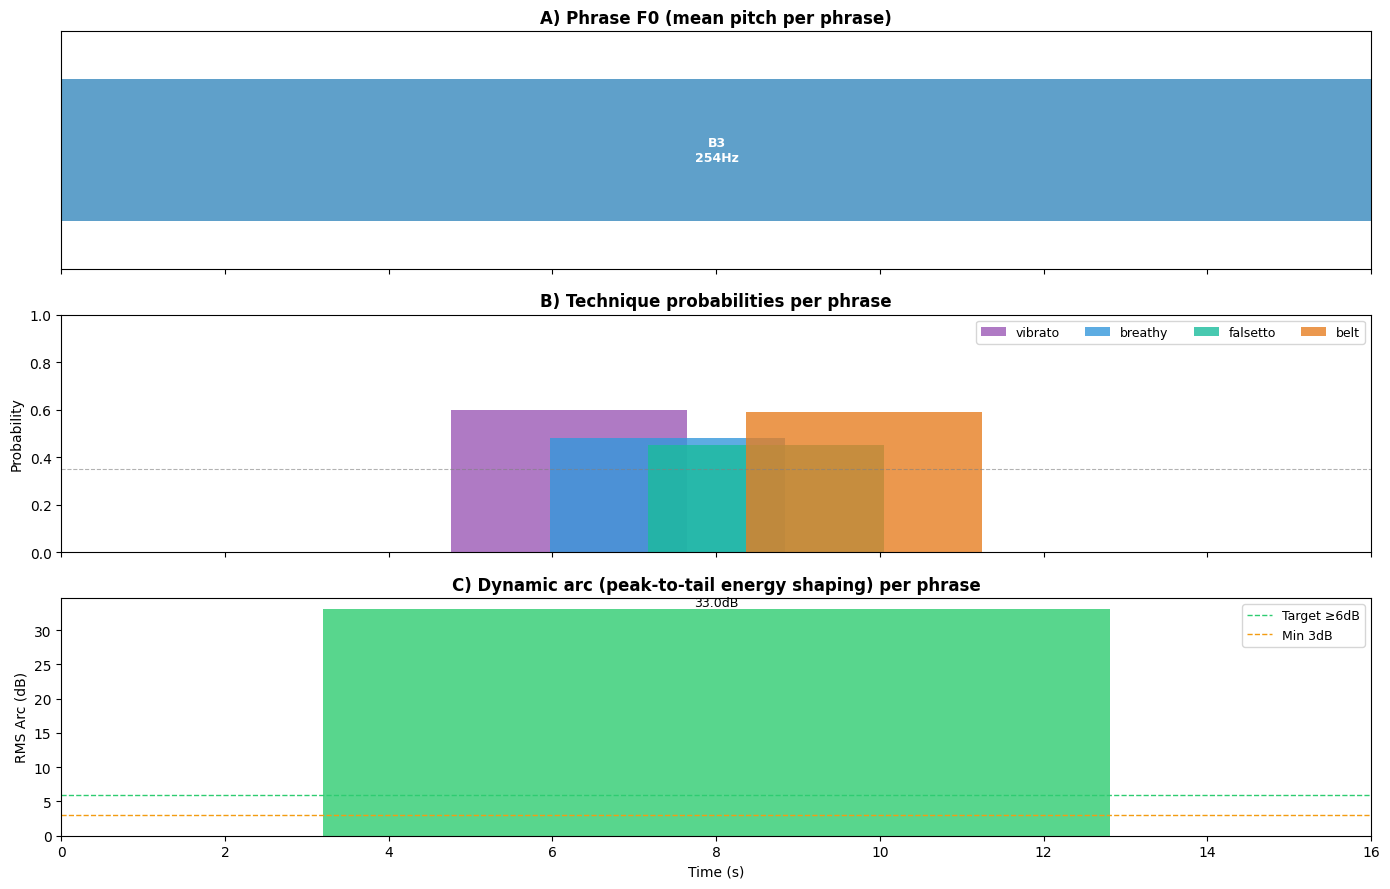

In [62]:
import librosa

TECHNIQUE_COLORS = {
    "vibrato": "#9b59b6",
    "breathy":  "#3498db",
    "falsetto": "#1abc9c",
    "belt":     "#e67e22",
}

phrases = report["phrases"]
clip_dur = report["clip_duration_s"]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# ── (A) F0 timeline ─────────────────────────────────────────────────
ax = axes[0]
for p in phrases:
    if p["f0_mean_hz"]:
        note = librosa.hz_to_note(p["f0_mean_hz"])
        ax.barh(0, p["end_s"] - p["start_s"], left=p["start_s"], height=0.6,
                color="#2980b9", alpha=0.75)
        ax.text((p["start_s"] + p["end_s"]) / 2, 0,
                f"{note}\n{p['f0_mean_hz']:.0f}Hz",
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax.set_yticks([])
ax.set_title("A) Phrase F0 (mean pitch per phrase)", fontweight="bold")
ax.set_xlim(0, clip_dur)
ax.set_ylim(-0.5, 0.5)

# ── (B) Technique probabilities per phrase ───────────────────────────
ax2 = axes[1]
bar_h = 0.18
tech_names = ["vibrato", "breathy", "falsetto", "belt"]
offsets = np.linspace(-0.27, 0.27, len(tech_names))
for p in phrases:
    mid = (p["start_s"] + p["end_s"]) / 2
    width = p["end_s"] - p["start_s"]
    for i, tname in enumerate(tech_names):
        prob = (p.get("technique") or {}).get(tname, 0) or 0
        ax2.bar(mid + offsets[i] * (width / (clip_dur * 0.15)),
                prob, width=width * 0.18,
                color=TECHNIQUE_COLORS[tname], alpha=0.8, label=tname if p == phrases[0] else "")
ax2.set_ylim(0, 1)
ax2.axhline(0.35, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax2.set_ylabel("Probability")
ax2.set_title("B) Technique probabilities per phrase", fontweight="bold")
ax2.legend(loc="upper right", ncol=4, fontsize=9)

# ── (C) Dynamic arc per phrase ───────────────────────────────────────
ax3 = axes[2]
for p in phrases:
    arc = p.get("rms_arc_db")
    mid = (p["start_s"] + p["end_s"]) / 2
    width = p["end_s"] - p["start_s"]
    color = "#2ecc71" if (arc or 0) >= 6 else ("#f39c12" if (arc or 0) >= 3 else "#e74c3c")
    ax3.bar(mid, arc or 0, width=width * 0.6, color=color, alpha=0.8)
    if arc:
        ax3.text(mid, arc + 0.1, f"{arc:.1f}dB", ha="center", va="bottom", fontsize=9)
ax3.axhline(6, color="#2ecc71", linestyle="--", linewidth=1, label="Target ≥6dB")
ax3.axhline(3, color="#f39c12", linestyle="--", linewidth=1, label="Min 3dB")
ax3.set_ylabel("RMS Arc (dB)")
ax3.set_xlabel("Time (s)")
ax3.set_title("C) Dynamic arc (peak-to-tail energy shaping) per phrase", fontweight="bold")
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Voice quality metrics

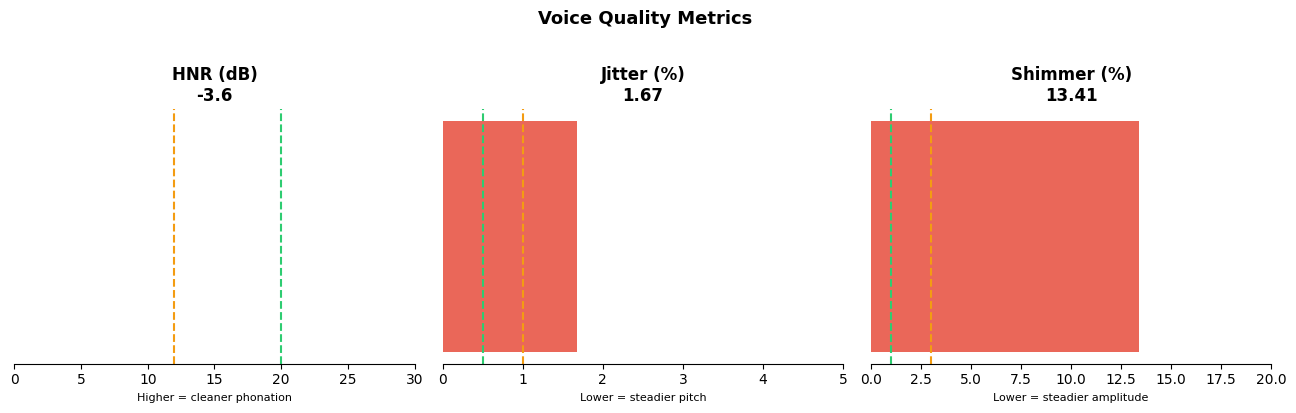


🎵 Vibrato Summary
  Phrases with vibrato : 0 / 1
  Rate                 : not detected Hz  (target 5-7 Hz)
  Depth                : not detected cents  (target 40-120 cents)


In [63]:
vq = report["voice_quality"]
vib = report["vibrato"]

# Reference ranges for each metric
RANGES = {
    "HNR (dB)":         (vq["hnr_mean_db"],      0,   30,  12,  20,  "Higher = cleaner phonation"),
    "Jitter (%)": (vq["jitter_mean_pct"],   0,   5,   1,  0.5,  "Lower = steadier pitch"),
    "Shimmer (%)":(vq["shimmer_mean_pct"] or 0, 0, 20,  3,  1,  "Lower = steadier amplitude"),
}

fig, axes = plt.subplots(1, len(RANGES), figsize=(13, 4))

for ax, (label, (val, lo, hi, warn_t, good_t, note)) in zip(axes, RANGES.items()):
    if val is None:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes, fontsize=14)
        ax.set_title(label)
        continue
    val_clipped = max(lo, min(hi, val))
    # Colour zones
    is_jitter_shimmer = label in ("Jitter (%)", "Shimmer (%)")
    if is_jitter_shimmer:
        color = "#2ecc71" if val <= good_t else ("#f39c12" if val <= warn_t else "#e74c3c")
    else:
        color = "#2ecc71" if val >= good_t else ("#f39c12" if val >= warn_t else "#e74c3c")
    ax.barh(0, val_clipped - lo, left=lo, height=0.4, color=color, alpha=0.85)
    ax.axvline(warn_t, color="#f39c12", linestyle="--", linewidth=1.5)
    ax.axvline(good_t, color="#2ecc71", linestyle="--", linewidth=1.5)
    ax.set_xlim(lo, hi)
    ax.set_yticks([])
    ax.set_title(f"{label}\n{round(val, 2)}", fontweight="bold")
    ax.set_xlabel(note, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Voice Quality Metrics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Vibrato detail
print("\n🎵 Vibrato Summary")
print(f"  Phrases with vibrato : {vib['n_vibrato_phrases']} / {report['n_phrases']}")
print(f"  Rate                 : {vib['rate_hz_mean'] or 'not detected'} Hz  (target 5-7 Hz)")
print(f"  Depth                : {vib['depth_cents_mean'] or 'not detected'} cents  (target 40-120 cents)")

## 5. Clip-level technique radar

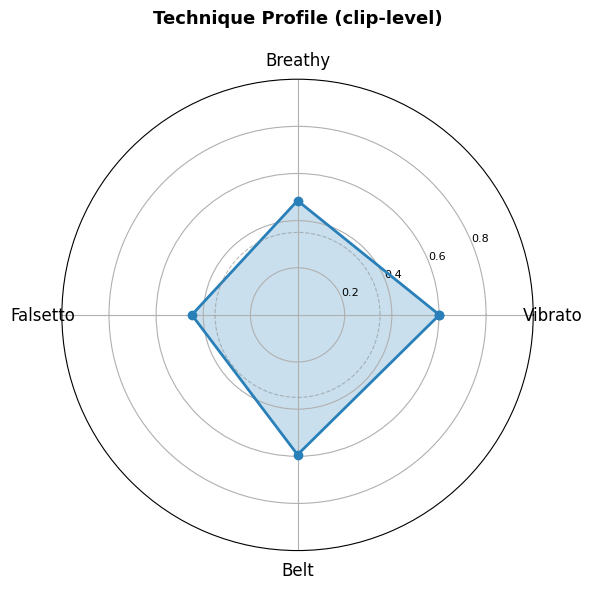


Raw values:
  vibrato    ████████████         0.602
  breathy    █████████            0.485
  falsetto   ████████             0.449
  belt       ███████████          0.593


In [64]:
tech = report["technique"]
names = list(tech.keys())
values = [tech[k] or 0 for k in names]

# Radar / spider chart
N = len(names)
angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]
values_plot = values + values[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values_plot, "o-", linewidth=2, color="#2980b9")
ax.fill(angles, values_plot, alpha=0.25, color="#2980b9")
ax.set_xticks(angles[:-1])
ax.set_xticklabels([n.capitalize() for n in names], fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=8)
ax.axhline(0.35, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("Technique Profile (clip-level)", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

print("\nRaw values:")
for k, v in tech.items():
    bar = "█" * int((v or 0) * 20)
    print(f"  {k:<10} {bar:<20} {round(v or 0, 3)}")

## 6. DTW reference comparison (optional)

In [65]:
ref = report.get("reference_comparison")
if ref:
    print("📐 Reference Comparison (DTW)")
    print(f"  Mean deviation   : {ref['mean_deviation_cents']:.1f} cents")
    print(f"  Max deviation    : {ref['max_deviation_cents']:.1f} cents")
    print(f"  DTW distance     : {ref['dtw_distance_cents']:.2f} (normalised)")

    # Grade
    dev = ref["mean_deviation_cents"]
    if dev < 25:
        grade = "Excellent — within 25 cents on average (< ¼ semitone)"
    elif dev < 50:
        grade = "Good — within half a semitone on average"
    elif dev < 100:
        grade = "Developing — within one semitone on average"
    else:
        grade = "Needs work — more than one semitone off on average"
    print(f"  Grade            : {grade}")
else:
    print("No reference file was uploaded — DTW comparison not available.")
    print("Re-run the analysis cell with REFERENCE_FILE set to compare against a target recording.")

No reference file was uploaded — DTW comparison not available.
Re-run the analysis cell with REFERENCE_FILE set to compare against a target recording.


## 7. Population context — amateur vs professional baseline

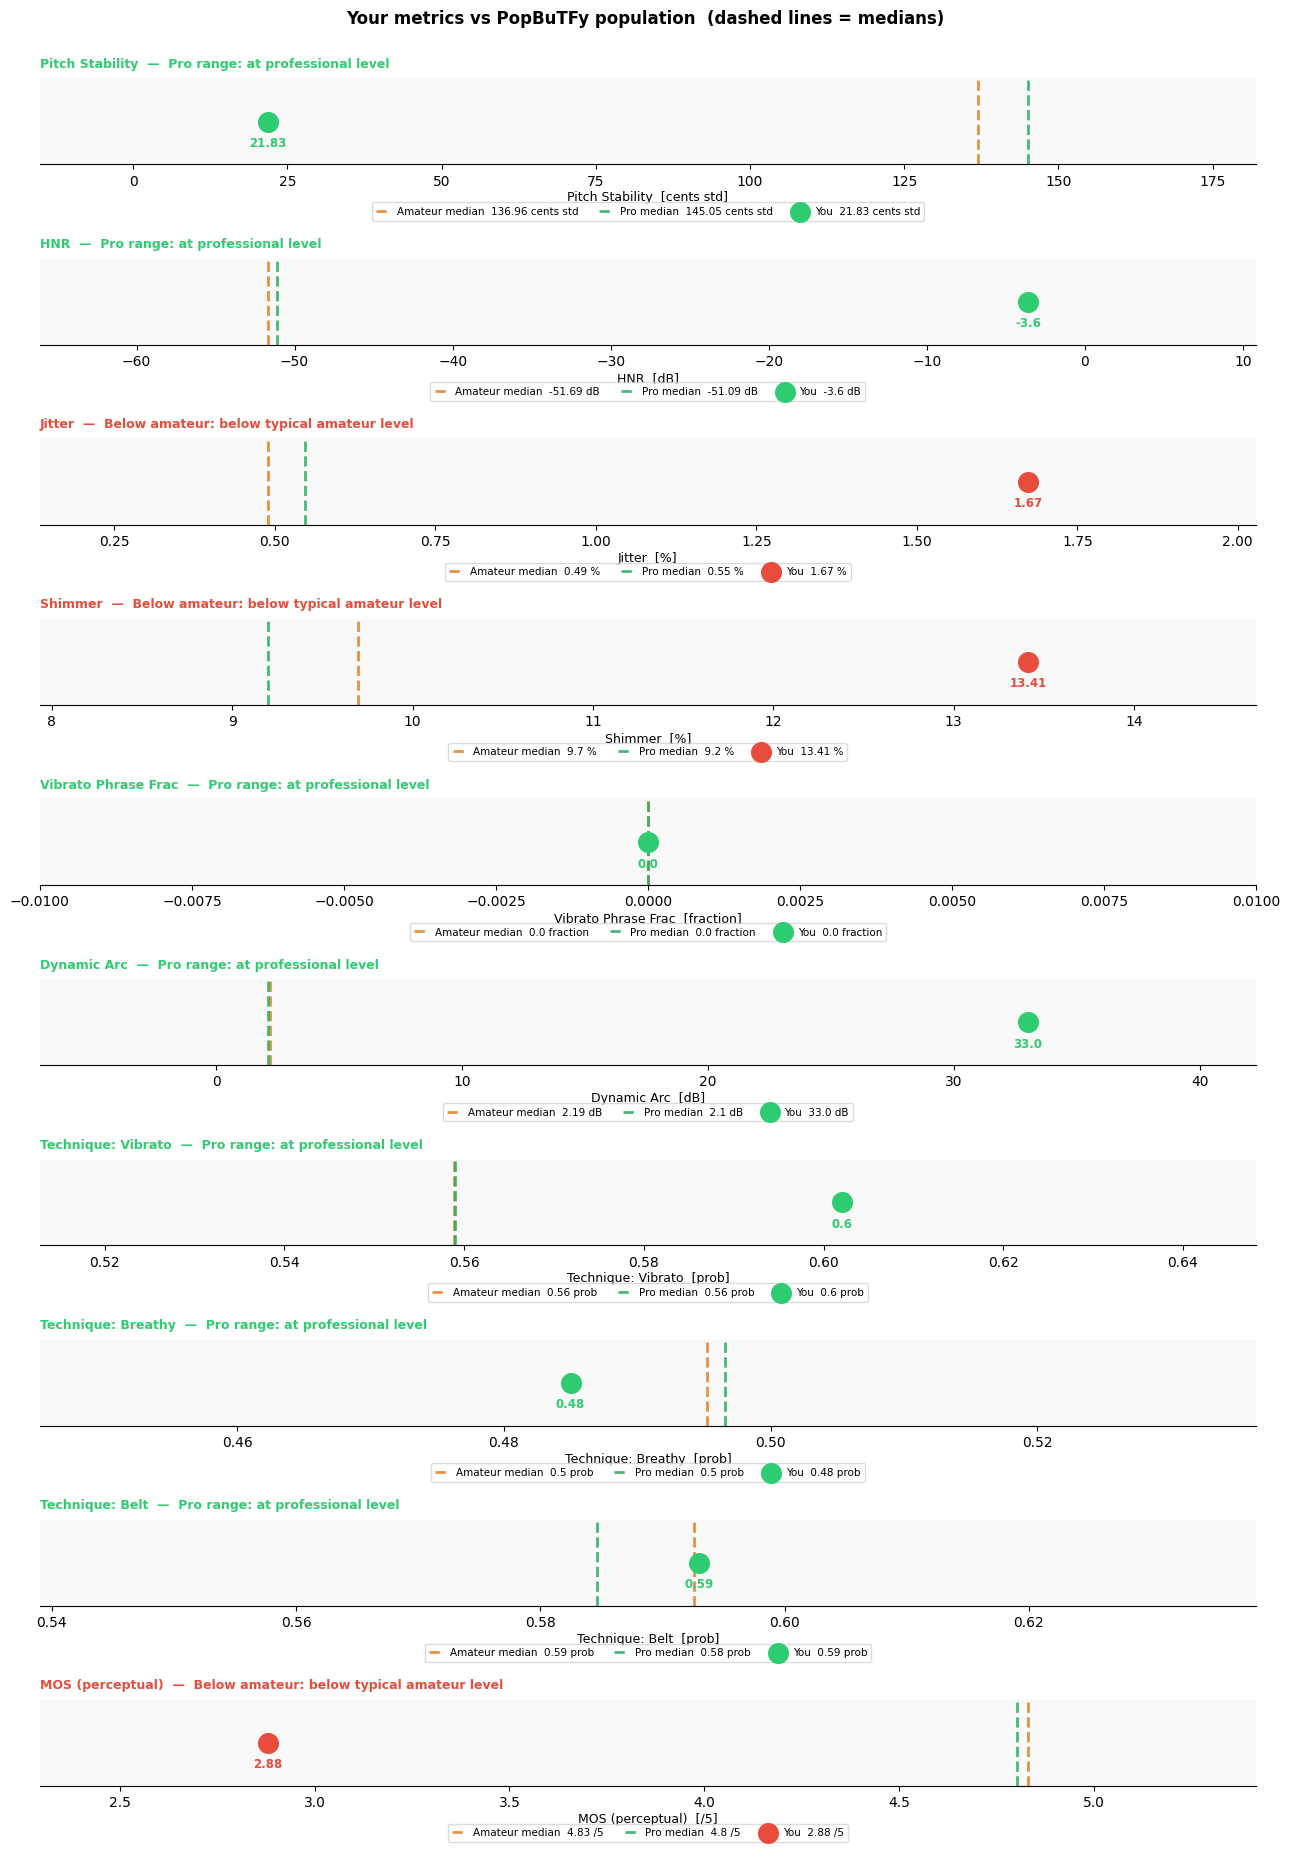

In [66]:
pop = report.get("population_context")

if not pop:
    print("No population context — run buildPopBuTFyBaselines.py first and ensure data/popbutfy_baselines.json exists.")
else:
    META = {
        "pitch_stability_cents": ("Pitch Stability",     "cents std", "lower"),
        "hnr_mean_db":           ("HNR",                 "dB",        "higher"),
        "jitter_mean_pct":       ("Jitter",              "%",         "lower"),
        "shimmer_mean_pct":      ("Shimmer",             "%",         "lower"),
        "vibrato_phrase_frac":   ("Vibrato Phrase Frac", "fraction",  "higher"),
        "rms_arc_mean_db":       ("Dynamic Arc",         "dB",        "higher"),
        "technique_vibrato":     ("Technique: Vibrato",  "prob",      "higher"),
        "technique_breathy":     ("Technique: Breathy",  "prob",      None),
        "technique_belt":        ("Technique: Belt",     "prob",      None),
        "mos":                   ("MOS (perceptual)",    "/5",        "higher"),
    }
    BAND_COLOR = {
        "pro_range":       "#2ecc71",
        "approaching_pro": "#27ae60",
        "amateur_range":   "#f39c12",
        "below_amateur":   "#e74c3c",
    }
    BAND_LABEL = {
        "pro_range":       "Pro range",
        "approaching_pro": "Approaching pro",
        "amateur_range":   "Amateur range",
        "below_amateur":   "Below amateur",
    }

    keys = [k for k in META if k in pop]
    n = len(keys)

    # Taller rows (1.8 each) so title, dot annotation, and legend don't collide
    fig, axes = plt.subplots(n, 1, figsize=(13, n * 1.8 + 1.0), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, key in zip(axes, keys):
        entry  = pop[key]
        label, unit, direction = META[key]
        your_val = entry.get("your_value")
        am_med   = entry.get("amateur_median")
        pro_med  = entry.get("pro_median")
        band     = entry.get("band", "unknown")
        interp   = entry.get("interpretation", "")

        vals = [v for v in [your_val, am_med, pro_med] if v is not None]
        if not vals:
            ax.axis("off")
            continue

        lo, hi = min(vals), max(vals)
        pad    = max((hi - lo) * 0.30, abs(hi) * 0.06 + 0.01)
        xlo, xhi = lo - pad, hi + pad

        band_col = BAND_COLOR.get(band, "#95a5a6")
        ax.set_facecolor("#f9f9f9")

        # Median reference lines
        if am_med is not None:
            ax.axvline(am_med, color="#e67e22", linewidth=2, linestyle="--", alpha=0.85,
                       label=f"Amateur median  {round(am_med, 2)} {unit}")
        if pro_med is not None:
            ax.axvline(pro_med, color="#27ae60", linewidth=2, linestyle="--", alpha=0.85,
                       label=f"Pro median  {round(pro_med, 2)} {unit}")

        # Your value dot — annotate BELOW the dot so it doesn't touch the title
        if your_val is not None:
            ax.scatter([your_val], [0], s=200, color=band_col, zorder=5,
                       label=f"You  {round(your_val, 2)} {unit}")
            ax.annotate(
                f"{round(your_val, 2)}",
                xy=(your_val, 0),
                xytext=(0, -18), textcoords="offset points",
                ha="center", fontsize=8.5, color=band_col, fontweight="bold",
            )

        ax.set_xlim(xlo, xhi)
        ax.set_yticks([])
        ax.set_ylim(-0.75, 0.75)
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)
        ax.set_xlabel(f"{label}  [{unit}]", fontsize=9, labelpad=2)

        # Title in colour above the row — enough pad so it clears the dot
        band_txt = BAND_LABEL.get(band, band)
        ax.set_title(
            f"{label}  —  {band_txt}: {interp}",
            fontsize=9, color=band_col, fontweight="bold",
            loc="left", pad=8,
        )

        # Legend anchored below the axis so it never overlaps the data
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.38),
            ncol=3,
            fontsize=7.5,
            framealpha=0.7,
            borderpad=0.4,
            handlelength=1.2,
        )

    fig.suptitle(
        "Your metrics vs PopBuTFy population  (dashed lines = medians)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.subplots_adjust(hspace=1.1)   # extra vertical gap so sub-axis legends fit
    plt.show()

## 8. Full JSON report

In [67]:
# Pretty-print the full report
print(json.dumps(report, indent=2, default=str))

{
  "clip_duration_s": 16.0,
  "n_phrases": 1,
  "pitch": {
    "f0_mean_hz": 254.1,
    "f0_stability_std_hz": 21.83
  },
  "dynamics": {
    "rms_mean_db": -47.9,
    "rms_range_db": 80.0
  },
  "voice_quality": {
    "hnr_mean_db": -3.6,
    "jitter_mean_pct": 1.673,
    "shimmer_mean_pct": 13.411,
    "h1_h2_mean_db": -108.1
  },
  "vibrato": {
    "phrase_fraction": 0.0,
    "rate_hz_mean": null,
    "depth_cents_mean": null,
    "n_vibrato_phrases": 0
  },
  "technique": {
    "vibrato": 0.601787805557251,
    "breathy": 0.48493123054504395,
    "falsetto": 0.448575884103775,
    "belt": 0.5933360457420349
  },
  "breath_control": {
    "n_breaths": 0,
    "n_onsets": 1
  },
  "phrases": [
    {
      "i": 1,
      "start_s": 0.0,
      "end_s": 16.01,
      "duration_s": 16.01,
      "f0_mean_hz": 254.1,
      "vibrato": false,
      "vib_rate_hz": null,
      "vib_depth": null,
      "rms_arc_db": 33.0,
      "technique": {
        "vibrato": 0.6,
        "breathy": 0.48,
     

## 10. PopBuTFy full-song DTW eval — amateur vs professional clips

Runs every clip in a PopBuTFy song folder pair through the `/analyse` endpoint with the
corresponding professional clip as reference. Prints a clip-by-clip DTW table and
song-level aggregate.

**How it works**: clips are numbered `_0.mp3`, `_1.mp3` … in both Amateur and Professional
folders. Clip `_N` in the amateur folder is paired with clip `_N` in the professional folder.
If lengths differ the shorter set is used.

In [68]:
import re, time

# ── Config ────────────────────────────────────────────────────────────────────
SONG_NAME   = "my_heart_will_go_on"   # ← change to any song in data/popbutfy/
SINGER      = "Female1"               # ← change to matching singer prefix

# Discover amateur + professional folder for this singer/song
def _find_folder(root, singer, song, level):
    """Return Path to the PopBuTFy folder matching singer + song + level."""
    pat = re.compile(
        rf"^{re.escape(singer)}#singing#{re.escape(song)}_{level}$",
        re.IGNORECASE,
    )
    for name in sorted(root.iterdir()):
        if name.is_dir() and pat.match(name.name):
            return name
    return None

popbutfy_root = _REPO / "data" / "popbutfy"
am_dir  = _find_folder(popbutfy_root, SINGER, SONG_NAME, "Amateur")
pro_dir = _find_folder(popbutfy_root, SINGER, SONG_NAME, "Professional")

if am_dir is None or pro_dir is None:
    print(f"Could not find folders for singer={SINGER!r} song={SONG_NAME!r}")
    print("Available folders:")
    for d in sorted(popbutfy_root.iterdir()):
        print(" ", d.name)
else:
    # Collect and sort clips by numeric suffix
    def _sorted_clips(folder):
        clips = sorted(folder.glob("*.mp3"), key=lambda p: int(re.search(r"_(\d+)\.mp3$", p.name).group(1)))
        return clips

    am_clips  = _sorted_clips(am_dir)
    pro_clips = _sorted_clips(pro_dir)
    n_pairs   = min(len(am_clips), len(pro_clips))

    print(f"Song       : {SONG_NAME}  |  Singer: {SINGER}")
    print(f"Amateur    : {am_dir.name}  ({len(am_clips)} clips)")
    print(f"Professional: {pro_dir.name}  ({len(pro_clips)} clips)")
    print(f"Pairs to eval: {n_pairs}\n")

    # DTW grades
    def _dtw_grade(dev):
        if dev is None: return "n/a"
        if dev < 25:    return "excellent"
        if dev < 50:    return "good"
        if dev < 100:   return "developing"
        return "needs_work"

    GRADE_EMOJI = {"excellent": "✅", "good": "✅", "developing": "⚠️", "needs_work": "❌", "n/a": "—"}

    # ── Header ────────────────────────────────────────────────────────────────
    print(f"{'Clip':<6} {'Mean dev (¢)':>13} {'Max dev (¢)':>12} {'DTW dist':>10} {'Grade':<14} {'Duration':>9}")
    print("─" * 68)

    rows = []
    for i, (am_path, pro_path) in enumerate(zip(am_clips[:n_pairs], pro_clips[:n_pairs])):
        try:
            with open(am_path, "rb") as af, open(pro_path, "rb") as pf:
                resp = requests.post(
                    f"{API_BASE}/analyse",
                    files={"audio": af, "reference": pf},
                    timeout=60,
                )
            if resp.status_code != 200:
                print(f"  clip_{i}: ERROR {resp.status_code}")
                continue

            rep = resp.json()
            ref = rep.get("reference_comparison")
            dur = rep.get("clip_duration_s", "?")

            mean_dev = ref["mean_deviation_cents"] if ref else None
            max_dev  = ref["max_deviation_cents"]  if ref else None
            dtw_dist = ref["dtw_distance_cents"]   if ref else None
            grade    = _dtw_grade(mean_dev)
            emoji    = GRADE_EMOJI[grade]

            print(f"  {i:<4} "
                  f"{str(round(mean_dev,1)) if mean_dev is not None else 'n/a':>13} "
                  f"{str(round(max_dev,1))  if max_dev  is not None else 'n/a':>12} "
                  f"{str(round(dtw_dist,2)) if dtw_dist is not None else 'n/a':>10} "
                  f"{emoji} {grade:<12} "
                  f"{str(round(dur,1))+'s':>9}")

            rows.append({"clip": i, "mean_dev": mean_dev, "max_dev": max_dev,
                         "dtw_dist": dtw_dist, "dur": dur, "grade": grade})

        except Exception as exc:
            print(f"  clip_{i}: exception — {exc}")

    # ── Song-level aggregate ──────────────────────────────────────────────────
    valid = [r for r in rows if r["mean_dev"] is not None]
    if valid:
        import statistics
        mean_devs = [r["mean_dev"] for r in valid]
        print("\n" + "─" * 68)
        print(f"  Song mean deviation : {round(statistics.mean(mean_devs), 1)} cents")
        print(f"  Song median dev     : {round(statistics.median(mean_devs), 1)} cents")
        print(f"  Song overall grade  : {_dtw_grade(statistics.mean(mean_devs))}")
        grade_counts = {}
        for r in valid:
            grade_counts[r["grade"]] = grade_counts.get(r["grade"], 0) + 1
        print(f"  Grade breakdown     : {grade_counts}")
        print(f"  Clips evaluated     : {len(valid)} / {n_pairs}")

Song       : my_heart_will_go_on  |  Singer: Female1
Amateur    : Female1#singing#my_heart_will_go_on_Amateur  (7 clips)
Professional: Female1#singing#my_heart_will_go_on_Professional  (7 clips)
Pairs to eval: 7

Clip    Mean dev (¢)  Max dev (¢)   DTW dist Grade           Duration
────────────────────────────────────────────────────────────────────
  0            101.3        288.6     101.32 ❌ needs_work        4.4s
  1             94.2       1067.3      94.23 ⚠️ developing        4.2s
  2            112.9        885.0     112.94 ❌ needs_work        2.7s
  3            122.1       1584.7      122.1 ❌ needs_work        7.8s
  4            189.4        488.7     189.38 ❌ needs_work        8.4s
  5            126.6       1535.2     126.63 ❌ needs_work        5.5s
  6             61.2       1113.1      61.15 ⚠️ developing        8.5s

────────────────────────────────────────────────────────────────────
  Song mean deviation : 115.4 cents
  Song median dev     : 112.9 cents
  Song overall